# MPP regional emissions: aggregation to Advanced / EMDE / China

The MPP model has been run for the `lc` (1.5C) pathway. **Two model runs** are combined here: smelters (`def`, product=`Aluminium`) and refineries (`def_refineries`, product=`Alumina`).

This notebook:
1. Loads the country-level asset stack and shows the current fleet.
2. Maps MPP's native regions to Advanced / EMDE / China using the IEA WEO NZE 2024 Advanced Economies country list.
3. Combines smelter and refinery emissions, aggregates per-region per-technology per-year to Advanced / EMDE / China.
4. Produces figures for emissions and carbon intensity trajectories.

Intensity is reported per tonne of **primary aluminium** (smelter output), so refinery emissions are attributed to the aluminium value chain but the denominator is aluminium production, not alumina.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import PchipInterpolator

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlepad": 10,
    "axes.grid": True,
    "grid.linewidth": 0.5,
    "grid.color": "#cccccc",
    "grid.alpha": 0.7,
    "legend.frameon": False,
    "figure.figsize": (11, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

REGION_COLORS = {
    "Advanced economies": "#0144ff",
    "Emerging markets and developing economies": "#e07a5f",
    "China": "#9b2226",
    "World": "#333333",
}

def smooth_line(x, y, n=300):
    xs = np.linspace(min(x), max(x), n)
    return xs, PchipInterpolator(x, y)(xs)

DATA_DIR = Path(".")
MPP_REPO = DATA_DIR / "mpp-shared-code" / "aluminium" / "data" / "lc"
MPP_OUTPUTS = MPP_REPO / "def" / "final" / "interface_outputs_aluminium_lc_def.csv"
MPP_STACK = MPP_REPO / "def" / "intermediate" / "initial_asset_stack.csv"

## 1. Country to Advanced / EMDE / China mapping

Advanced Economies list = IEA WEO NZE 2024 classification, verbatim from the SBTi Power spec.

In [2]:
ADVANCED_COUNTRIES = {
    "Australia", "Austria", "Belgium", "Canada", "Chile", "Colombia",
    "Costa Rica", "Czechia", "Czech Republic", "Denmark", "Estonia", "Finland",
    "France", "Germany", "Greece", "Hungary", "Iceland", "Ireland", "Israel",
    "Italy", "Japan", "Korea", "South Korea", "Republic of Korea",
    "Latvia", "Lithuania", "Luxembourg", "Mexico", "Netherlands",
    "New Zealand", "Norway", "Poland", "Portugal", "Slovak Republic", "Slovakia",
    "Slovenia", "Spain", "Sweden", "Switzerland", "Turkey", "Turkiye",
    "United Kingdom", "United States", "Bulgaria", "Croatia", "Cyprus",
    "Malta", "Romania",
}

def classify(country):
    if country == "China":
        return "China"
    if country in ADVANCED_COUNTRIES:
        return "Advanced economies"
    return "Emerging markets and developing economies"

# Load the initial asset stack (country-level)
stack = pd.read_csv(MPP_STACK)

# For MPP regions that map cleanly to one AE/EMDE/China grouping, use the dict below.
# For Rest of Europe (only mixed bucket at the smelter level), compute AE share by 2020 capacity.
def region_is_clean(region):
    if region.startswith("China -"):
        return "China"
    return {
        "US": "Advanced economies",
        "Canada": "Advanced economies",
        "Scandinavia": "Advanced economies",
        "Oceania": "Advanced economies",
        "Russia": "Emerging markets and developing economies",
        "Middle East": "Emerging markets and developing economies",
        "Africa": "Emerging markets and developing economies",
        "South America": "Emerging markets and developing economies",
        "Rest of Asia": "Emerging markets and developing economies",
    }.get(region)

# Compute AE share for Rest of Europe
mixed = stack[stack["region"] == "Rest of Europe"].copy()
mixed["group"] = mixed["country"].map(classify)
mixed_split = mixed.groupby("group")["annual_production_capacity"].sum()
ae_share_roe = mixed_split.get("Advanced economies", 0) / mixed_split.sum()
print("Rest of Europe smelter capacity split (Mt Al / yr):")
print(mixed_split)
print(f"\nAE share within Rest of Europe = {ae_share_roe:.1%}")

Rest of Europe smelter capacity split (Mt Al / yr):
group
Advanced economies                          2.331
Emerging markets and developing economies   0.470
Name: annual_production_capacity, dtype: float64

AE share within Rest of Europe = 83.2%


## 2. Load MPP model outputs and inspect

The `interface_outputs_aluminium_lc_def.csv` is the long-format detailed output, one row per sector x product x region x technology x year x parameter.

In [3]:
# Combined smelter + refinery outputs. Two MPP model runs.
MPP_OUTPUTS_SMELTER = MPP_REPO / "def" / "final" / "interface_outputs_aluminium_lc_def.csv"
MPP_OUTPUTS_REFINERY = MPP_REPO / "def_refineries" / "final" / "interface_outputs_aluminium_lc_def_refineries.csv"

smelter = pd.read_csv(MPP_OUTPUTS_SMELTER)
refinery = pd.read_csv(MPP_OUTPUTS_REFINERY)
outputs = pd.concat([smelter, refinery], ignore_index=True)

print("Smelter rows:", len(smelter), "product:", smelter["product"].unique())
print("Refinery rows:", len(refinery), "product:", refinery["product"].unique())
print("Combined rows:", len(outputs))
print("\nCombined regions:", sorted(outputs["region"].unique()))
print("\nEmissions parameters:")
print(outputs[outputs["parameter_group"]=="Emissions"]["parameter"].value_counts())

Smelter rows: 60719 product: ['Aluminium']
Refinery rows: 35083 product: ['Alumina']
Combined rows: 95802

Combined regions: ['Africa', 'Canada', 'China - Central', 'China - East', 'China - North', 'China - North East', 'China - North West', 'China - South', 'Middle East', 'Oceania', 'Rest of Asia', 'Rest of Europe', 'Russia', 'Scandinavia', 'South America', 'US']

Emissions parameters:
parameter
CO2 Scope1             2758
CO2 Scope2             2758
CO2 Scope1 captured    2758
Name: count, dtype: int64


## 3. Aggregate absolute emissions to Advanced / EMDE / China

Method:
- Absolute emissions (Mt CO2) sum across technologies within each region-year, then re-group by AE/EMDE/China.
- For `Rest of Europe` we split the region's total emissions by the AE / EMDE capacity share computed above. This is a static split based on 2020 fleet composition. MPP does not resolve new-build country allocation within a region.

In [4]:
# Absolute emissions (Mt CO2), Scope 1 + Scope 2 (exclude captured)
emis = outputs[
    (outputs["parameter_group"] == "Emissions")
    & (outputs["parameter"].isin(["CO2 Scope1", "CO2 Scope2"]))
    & (outputs["unit"] == "Mt CO2")
].copy()

# Sum S1 + S2 per region-year (aggregating over technologies and scopes)
emis_by_ry = emis.groupby(["region", "year"], as_index=False)["value"].sum()
emis_by_ry = emis_by_ry.rename(columns={"value": "emissions_mt_co2"})

def apply_mapping(row, col):
    clean = region_is_clean(row["region"])
    if clean is not None:
        return pd.Series({clean: row[col]})
    if row["region"] == "Rest of Europe":
        return pd.Series({
            "Advanced economies": row[col] * ae_share_roe,
            "Emerging markets and developing economies": row[col] * (1 - ae_share_roe),
        })
    raise ValueError(f"Unmapped region: {row['region']}")

emis_split = emis_by_ry.apply(lambda r: apply_mapping(r, "emissions_mt_co2"), axis=1).fillna(0)
emis_split["year"] = emis_by_ry["year"].values
emis_agg = emis_split.groupby("year").sum().reset_index()
emis_agg["World"] = emis_agg[
    ["Advanced economies", "Emerging markets and developing economies", "China"]
].sum(axis=1)

print("Aggregated aluminium sector emissions (Mt CO2/yr):")
print(emis_agg[emis_agg["year"].isin([2020, 2030, 2040, 2050])].round(1))

Aggregated aluminium sector emissions (Mt CO2/yr):
    year  Advanced economies   China  \
0   2020              59.100 607.900   
10  2030              44.500 492.600   
20  2040              66.800 101.300   
30  2050              66.900  17.400   

    Emerging markets and developing economies   World  
0                                     193.100 860.100  
10                                    145.600 682.600  
20                                     74.000 242.100  
30                                     60.500 144.700  


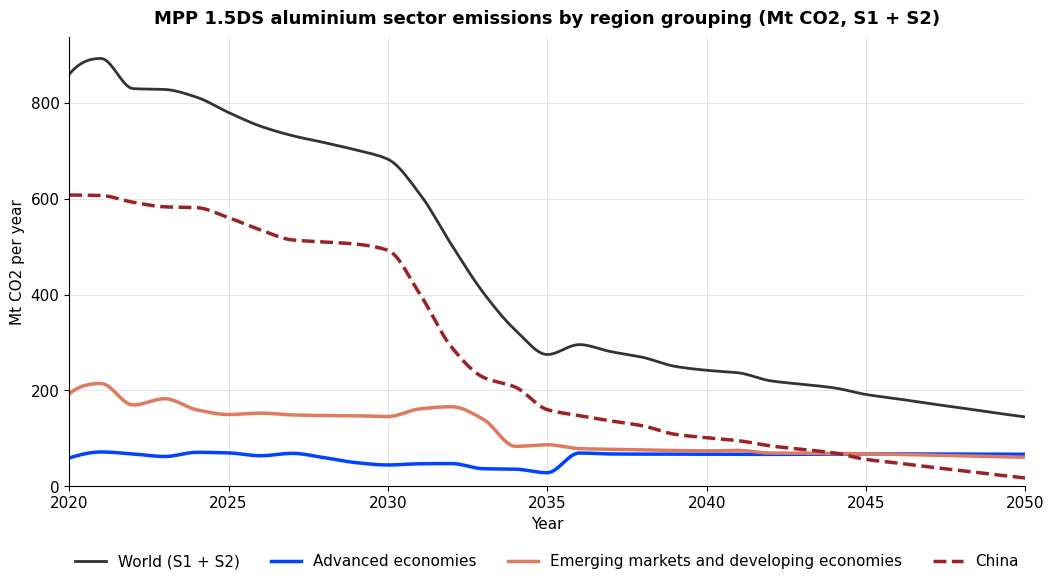

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

for reg in ["World", "Advanced economies", "Emerging markets and developing economies", "China"]:
    style = "--" if reg == "China" else "-"
    lw = 2.0 if reg == "World" else 2.5
    x, y = smooth_line(emis_agg["year"].values, emis_agg[reg].values)
    label = "World (S1 + S2)" if reg == "World" else reg
    ax.plot(x, y, color=REGION_COLORS[reg], linewidth=lw, linestyle=style, label=label)

ax.set_title("MPP 1.5DS aluminium sector emissions by region grouping (Mt CO2, S1 + S2)")
ax.set_xlabel("Year")
ax.set_ylabel("Mt CO2 per year")
ax.set_xlim(2020, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.set_ylim(0, None)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

### Scope split within the aggregate

Same aggregation, but keeping S1 and S2 separate. S1 = direct process + captive fossil power; S2 = grid electricity.

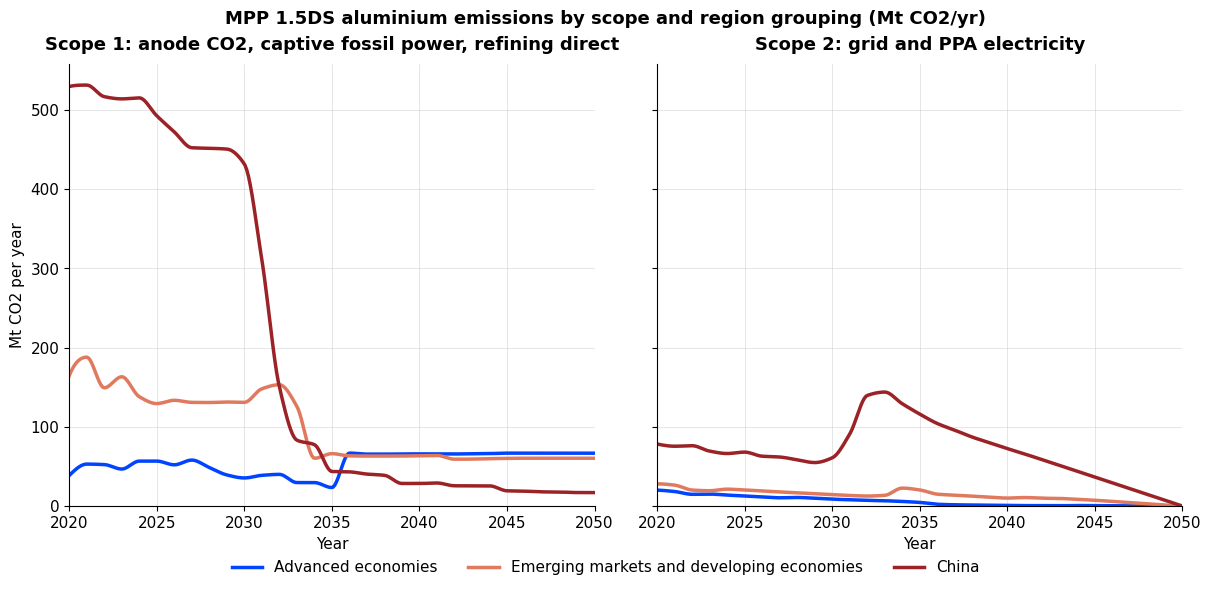

In [6]:
def aggregate_by_scope(scope_name):
    e = outputs[
        (outputs["parameter_group"] == "Emissions")
        & (outputs["parameter"] == scope_name)
        & (outputs["unit"] == "Mt CO2")
    ].copy()
    e_by_ry = e.groupby(["region", "year"], as_index=False)["value"].sum().rename(columns={"value":"v"})
    split = e_by_ry.apply(lambda r: apply_mapping(r, "v"), axis=1).fillna(0)
    split["year"] = e_by_ry["year"].values
    return split.groupby("year").sum().reset_index()

s1 = aggregate_by_scope("CO2 Scope1")
s2 = aggregate_by_scope("CO2 Scope2")

ymax = max(
    s1[["Advanced economies", "Emerging markets and developing economies", "China"]].values.max(),
    s2[["Advanced economies", "Emerging markets and developing economies", "China"]].values.max(),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True, constrained_layout=True,
                          gridspec_kw={"wspace": 0.04})

panels = [
    (axes[0], s1, "Scope 1: anode CO2, captive fossil power, refining direct"),
    (axes[1], s2, "Scope 2: grid and PPA electricity"),
]
handles, labels = None, None
for ax, df, title in panels:
    for reg in ["Advanced economies", "Emerging markets and developing economies", "China"]:
        x, y = smooth_line(df["year"].values, df[reg].values)
        ax.plot(x, y, color=REGION_COLORS[reg], linewidth=2.5, label=reg)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_xlim(2020, 2050)
    ax.set_xticks(range(2020, 2051, 5))
    ax.set_ylim(0, ymax * 1.05)
    handles, labels = ax.get_legend_handles_labels()

axes[0].set_ylabel("Mt CO2 per year")
fig.suptitle("MPP 1.5DS aluminium emissions by scope and region grouping (Mt CO2/yr)",
             fontsize=13, fontweight="bold")
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
plt.show()

## 4. Aggregate carbon intensity to Advanced / EMDE / China

Intensity aggregation needs production weights, since it is a ratio. Method:
1. Get production (Mt Al) per region-year from the model.
2. Get absolute emissions (Mt CO2) per region-year (computed above).
3. AE/EMDE/China intensity = sum of grouped emissions / sum of grouped production.

In [7]:
# Production Mt Al per region per year (SMELTER ONLY — the primary aluminium metric)
prod = outputs[
    (outputs["parameter_group"] == "Production")
    & (outputs["product"] == "Aluminium")
    & (outputs["unit"].str.contains("Mt", na=False))
].copy()

prod_by_ry = prod.groupby(["region", "year"], as_index=False)["value"].sum().rename(columns={"value":"prod_mt"})

prod_split = prod_by_ry.apply(lambda r: apply_mapping(r, "prod_mt"), axis=1).fillna(0)
prod_split["year"] = prod_by_ry["year"].values
prod_agg = prod_split.groupby("year").sum().reset_index()
prod_agg["World"] = prod_agg[["Advanced economies", "Emerging markets and developing economies", "China"]].sum(axis=1)

intensity = pd.DataFrame({"year": emis_agg["year"]})
for reg in ["Advanced economies", "Emerging markets and developing economies", "China", "World"]:
    intensity[reg] = emis_agg[reg] / prod_agg[reg]

print("Regional intensity (t CO2 / t Al) at 5-year intervals:")
print(intensity[intensity["year"].isin([2020, 2025, 2030, 2035, 2040, 2045, 2050])].round(3))

Regional intensity (t CO2 / t Al) at 5-year intervals:
    year  Advanced economies  Emerging markets and developing economies  \
0   2020               7.643                                     10.109   
5   2025               7.643                                      8.028   
10  2030               4.111                                      7.553   
15  2035               2.288                                      3.859   
20  2040               4.772                                      3.178   
25  2045               3.721                                      2.275   
30  2050               3.678                                      2.015   

    China  World  
0  15.798 13.168  
5  15.265 12.095  
10 13.816 10.383  
15  4.236  3.788  
20  2.547  3.142  
25  1.395  2.171  
30  0.431  1.636  


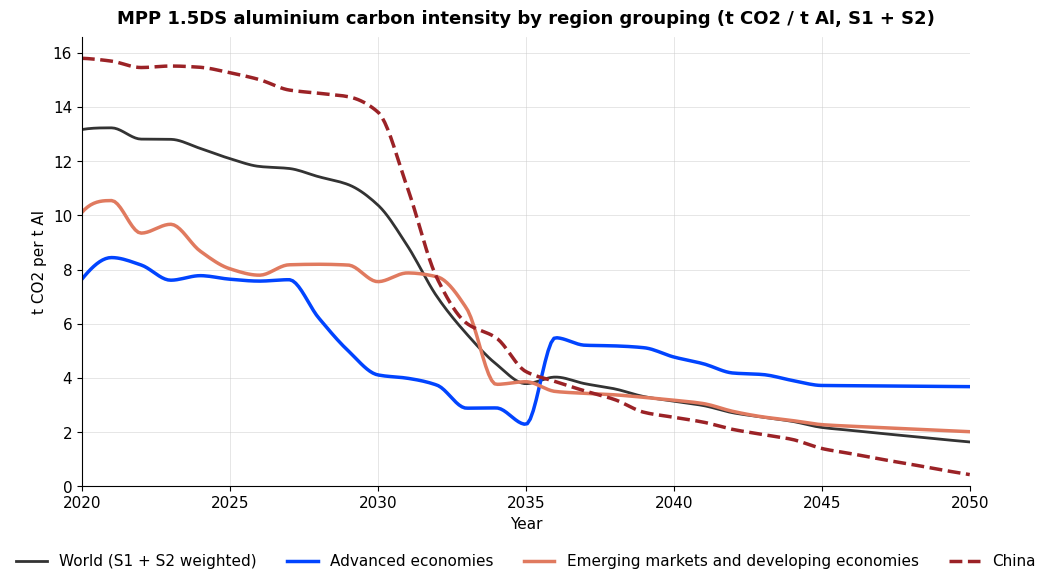

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

for reg in ["World", "Advanced economies", "Emerging markets and developing economies", "China"]:
    style = "--" if reg == "China" else "-"
    lw = 2.0 if reg == "World" else 2.5
    x, y = smooth_line(intensity["year"].values, intensity[reg].values)
    label = "World (S1 + S2 weighted)" if reg == "World" else reg
    ax.plot(x, y, color=REGION_COLORS[reg], linewidth=lw, linestyle=style, label=label)

ax.set_title("MPP 1.5DS aluminium carbon intensity by region grouping (t CO2 / t Al, S1 + S2)")
ax.set_xlabel("Year")
ax.set_ylabel("t CO2 per t Al")
ax.set_xlim(2020, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.set_ylim(0, None)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

### 4a. Primary aluminium intensity — Scope 1 only

Same regional aggregation, but restricted to **direct process emissions only** (`CO2 Scope1`): anode oxidation, PFC from smelters, and fuel combustion in refinery boilers/calciners. Excludes grid and captive-power S2, which dominates the aluminium footprint globally.

**Regional-compatibility caveats — flagging, not fixing:**

1. **Rest of Europe (RoE) is mixed AE + EMDE and split by a single static capacity share.** The current `ae_share_roe` (83.2%) is computed from the **smelter** asset stack only, then applied to *both* smelter and refinery emissions. This is inaccurate for refineries: RoE refinery capacity is dominated by Ukraine (1.76 Mt/yr alumina, EMDE) plus Bosnia + Romania (EMDE), while RoE smelter capacity is mostly AE (France, Germany, Italy, UK, NL, Spain). The true refinery AE share of RoE is materially lower than 83%. Result: refinery emissions attributed to AE are overstated, EMDE understated. Doing this cleanly would require computing `ae_share_roe_refinery` separately and applying it to alumina rows only.
2. **The RoE split is static in time.** MPP does not resolve within-region country allocation for new-build or transitioning assets, so the AE share is held constant. If AE-country smelters retire faster than EMDE-country ones inside RoE (or vice versa), this split drifts from reality.
3. **Oceania is 100% AE** (Australia + New Zealand in both smelter and refinery stacks) → clean assignment, no issue.
4. **China is intact** (all six China sub-regions map cleanly to China) → no issue.

Bottom line: for AE vs EMDE at the aluminium sector level, the RoE refinery-share issue is the only material inaccuracy. Impact scales with how much of the sector's total emissions live in RoE refineries — modest globally but non-trivial for AE/EMDE intensity levels.

In [ ]:
# Scope 1 only intensity.
# aggregate_by_scope() (defined above) already sums CO2 Scope1 per region-year and applies the AE/EMDE/China mapping.
# Reuse it, then divide by the same production denominator used in section 4.

emis_s1 = aggregate_by_scope("CO2 Scope1")
emis_s1["World"] = emis_s1[
    ["Advanced economies", "Emerging markets and developing economies", "China"]
].sum(axis=1)

intensity_s1 = pd.DataFrame({"year": emis_s1["year"]})
for reg in ["Advanced economies", "Emerging markets and developing economies", "China", "World"]:
    intensity_s1[reg] = emis_s1[reg] / prod_agg[reg]

print("Regional Scope 1 intensity (t CO2 / t Al) at 5-year intervals:")
print(intensity_s1[intensity_s1["year"].isin([2020, 2025, 2030, 2035, 2040, 2045, 2050])].round(3))

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

for reg in ["World", "Advanced economies", "Emerging markets and developing economies", "China"]:
    style = "--" if reg == "China" else "-"
    lw = 2.0 if reg == "World" else 2.5
    x, y = smooth_line(intensity_s1["year"].values, intensity_s1[reg].values)
    label = "World (S1 weighted)" if reg == "World" else reg
    ax.plot(x, y, color=REGION_COLORS[reg], linewidth=lw, linestyle=style, label=label)

ax.set_title("MPP 1.5DS primary aluminium Scope 1 intensity by region grouping (t CO2 / t Al)")
ax.set_xlabel("Year")
ax.set_ylabel("t CO2 per t Al (Scope 1 only)")
ax.set_xlim(2020, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.set_ylim(0, None)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

### 4b. Secondary aluminium intensity — not included

MPP does not model secondary aluminium. The smelter run (`PRODUCTS=["Aluminium"]`) covers only primary electrolysis technologies (Carbon Anode / Inert Anode × power source, ± CCS); there is no re-melt or scrap pathway in the code, the tech list, the demand input, or the emissions input. MPP's demand curve (65 Mt in 2020 → 205 Mt in 2050) matches IAI's global *primary* aluminium demand — secondary is netted out of demand exogenously, not solved as an asset stack.

IAI 1.5 does report a global "Recycled Aluminium (Gate to Gate)" intensity (0.59 → 0.10 t CO2e/t Al, Table 4), but this is a **total** (cradle-to-gate) figure, not a strict Scope 1 line, and is global only (no AE/EMDE/China resolution). Given the request is strict Scope 1 only, and no source provides a Scope 1-only secondary intensity at the required boundary, no secondary intensity figure is produced here.

## 5. Regional production (activity)

For completeness, the same AE/EMDE/China split applied to aluminium production.

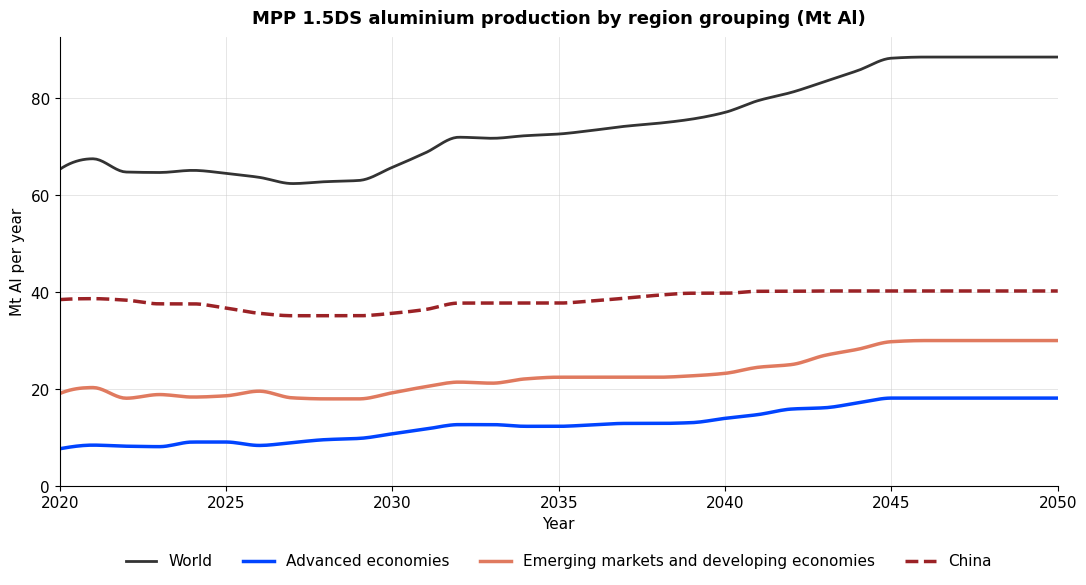

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

for reg in ["World", "Advanced economies", "Emerging markets and developing economies", "China"]:
    style = "--" if reg == "China" else "-"
    lw = 2.0 if reg == "World" else 2.5
    x, y = smooth_line(prod_agg["year"].values, prod_agg[reg].values)
    ax.plot(x, y, color=REGION_COLORS[reg], linewidth=lw, linestyle=style, label=reg)

ax.set_title("MPP 1.5DS aluminium production by region grouping (Mt Al)")
ax.set_xlabel("Year")
ax.set_ylabel("Mt Al per year")
ax.set_xlim(2020, 2050)
ax.set_xticks(range(2020, 2051, 5))
ax.set_ylim(0, None)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

## 6. Fleet snapshot (2020 baseline, for context)

Current smelter fleet by AE/EMDE/China and by technology. Starting point for the model transitions.

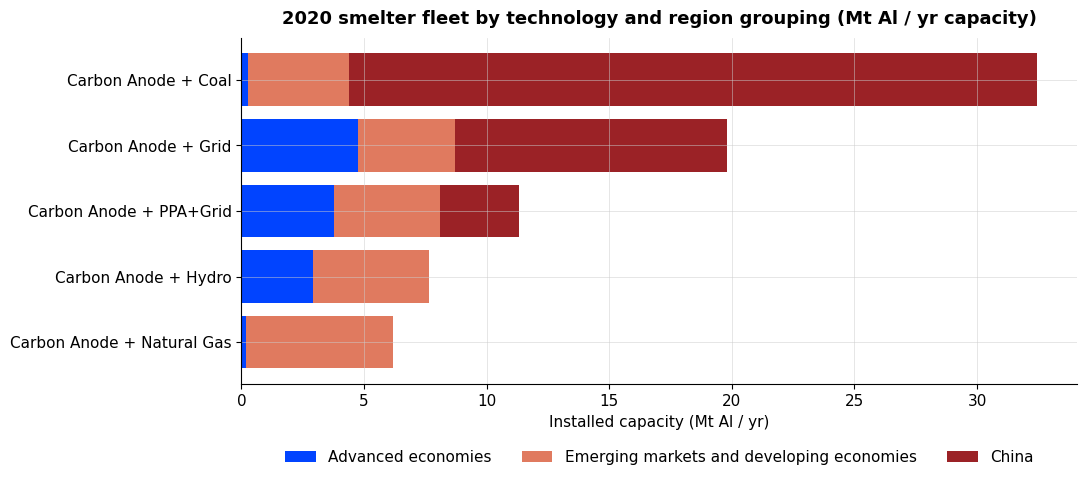

In [10]:
stack["group"] = stack.apply(
    lambda row: "China" if str(row["region"]).startswith("China") else classify(row["country"]),
    axis=1
)

fleet = stack.groupby(["group", "technology"], as_index=False)["annual_production_capacity"].sum()
fleet_pivot = fleet.pivot(index="technology", columns="group", values="annual_production_capacity").fillna(0)
fleet_pivot["Total"] = fleet_pivot.sum(axis=1)
fleet_pivot = fleet_pivot.sort_values("Total", ascending=False).drop(columns="Total")

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(fleet_pivot))
for reg in ["Advanced economies", "Emerging markets and developing economies", "China"]:
    if reg in fleet_pivot.columns:
        vals = fleet_pivot[reg].values
        ax.barh(fleet_pivot.index, vals, left=bottom, color=REGION_COLORS[reg], label=reg)
        bottom += vals
ax.set_title("2020 smelter fleet by technology and region grouping (Mt Al / yr capacity)")
ax.set_xlabel("Installed capacity (Mt Al / yr)")
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

## 7. Export aggregated results

Regional emissions, intensity, and production written to `mpp_lc_aggregated.csv` for downstream use.

In [11]:
rows = []
for reg in ["Advanced economies", "Emerging markets and developing economies", "China", "World"]:
    for _, r in emis_agg.iterrows():
        rows.append({"region": reg, "year": r["year"], "parameter": "Emissions S1+S2", "unit": "Mt CO2/yr", "value": r[reg]})
    for _, r in intensity.iterrows():
        rows.append({"region": reg, "year": r["year"], "parameter": "Intensity S1+S2", "unit": "t CO2 / t Al", "value": r[reg]})
    for _, r in prod_agg.iterrows():
        rows.append({"region": reg, "year": r["year"], "parameter": "Production", "unit": "Mt Al/yr", "value": r[reg]})

agg_out = pd.DataFrame(rows)
agg_out.to_csv("mpp_lc_aggregated.csv", index=False)
print(f"Wrote {len(agg_out)} rows to mpp_lc_aggregated.csv")
agg_out[agg_out["year"].isin([2020, 2030, 2040, 2050])].pivot(
    index=["region","parameter","unit"], columns="year", values="value"
).round(2)

Wrote 372 rows to mpp_lc_aggregated.csv


year                                                                    2,020.000  \
region                                    parameter       unit                      
Advanced economies                        Emissions S1+S2 Mt CO2/yr        59.110   
                                          Intensity S1+S2 t CO2 / t Al      7.640   
                                          Production      Mt Al/yr          7.730   
China                                     Emissions S1+S2 Mt CO2/yr       607.900   
                                          Intensity S1+S2 t CO2 / t Al     15.800   
                                          Production      Mt Al/yr         38.480   
Emerging markets and developing economies Emissions S1+S2 Mt CO2/yr       193.080   
                                          Intensity S1+S2 t CO2 / t Al     10.110   
                                          Production      Mt Al/yr         19.100   
World                                     Emissions S1+S2 Mt CO2/yr       860.090   
                                          Intensity S1+S2 t CO2 / t Al     13.170   
                                          Production      Mt Al/yr         65.310   

year                                                                    2,030.000  \
region                                    parameter       unit                      
Advanced economies                        Emissions S1+S2 Mt CO2/yr        44.470   
                                          Intensity S1+S2 t CO2 / t Al      4.110   
                                          Production      Mt Al/yr         10.820   
China                                     Emissions S1+S2 Mt CO2/yr       492.560   
                                          Intensity S1+S2 t CO2 / t Al     13.820   
                                          Production      Mt Al/yr         35.650   
Emerging markets and developing economies Emissions S1+S2 Mt CO2/yr       145.560   
                                          Intensity S1+S2 t CO2 / t Al      7.550   
                                          Production      Mt Al/yr         19.270   
World                                     Emissions S1+S2 Mt CO2/yr       682.590   
                                          Intensity S1+S2 t CO2 / t Al     10.380   
                                          Production      Mt Al/yr         65.740   

year                                                                    2,040.000  \
region                                    parameter       unit                      
Advanced economies                        Emissions S1+S2 Mt CO2/yr        66.820   
                                          Intensity S1+S2 t CO2 / t Al      4.770   
                                          Production      Mt Al/yr         14.000   
China                                     Emissions S1+S2 Mt CO2/yr       101.340   
                                          Intensity S1+S2 t CO2 / t Al      2.550   
                                          Production      Mt Al/yr         39.790   
Emerging markets and developing economies Emissions S1+S2 Mt CO2/yr        73.960   
                                          Intensity S1+S2 t CO2 / t Al      3.180   
                                          Production      Mt Al/yr         23.280   
World                                     Emissions S1+S2 Mt CO2/yr       242.130   
                                          Intensity S1+S2 t CO2 / t Al      3.140   
                                          Production      Mt Al/yr         77.070   

year                                                                    2,050.000  
region                                    parameter       unit                     
Advanced economies                        Emissions S1+S2 Mt CO2/yr        66.860  
                                          Intensity S1+S2 t CO2 / t Al      3.680  
                                          Production      Mt Al/yr         18.180  
China  